# Transformer-Based Model Evaluation for Medical Text Classification

## Project Overview
This project evaluates and compares traditional machine learning models and transformer-based models for medical text classification using clinical transcription data.

## Importing the Core Library
In this step, we import the `pandas` library, which will help us load and work with the dataset in tabular form.

## Confirming the Pandas Version
In this step, we check the installed version of `pandas` to make sure the library is available and working correctly in the current notebook environment.

In [5]:
import sys
import warnings
import pandas as pd
import numpy as np
import os

warnings.filterwarnings("ignore")

print("Python executable:", sys.executable)
print("Pandas version:", pd.__version__)
print("Current working directory:", os.getcwd())

Python executable: c:\Users\dubey\Documents\UC_GitLab\.venv_global\Scripts\python.exe
Pandas version: 2.3.3
Current working directory: c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\Project - Transformer-Based Model Evaluation


In [6]:
data_path = r"c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\Project - Transformer-Based Model Evaluation\data\mtsamples.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (4999, 6)

Columns:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [7]:
print("Basic dataset info:")
print(df.info())

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nNumber of unique medical specialties:")
print(df["medical_specialty"].nunique())

print("\nFirst 10 medical specialties:")
print(df["medical_specialty"].dropna().unique()[:10])

Basic dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB
None

Missing values by column:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

Number of unique medical specialties:
40

First 10 medical specialties:
[' Allergy / Immunology' ' Bariatrics' ' Cardiovascular / Pulmonary'
 ' Neurology' ' Dentistry' ' Urology' ' General Medicine' ' Surgery'
 ' Speech - Language' ' SOAP / Cha

## Data Cleaning and Column Selection
In this step, we keep only the columns needed for the classification task and clean the dataset.  
We will use:

- `medical_specialty` as the target label
- `transcription` as the input text

We will also remove rows with missing transcription text and strip unnecessary spaces from both the labels and the text.

In [8]:
# Keep only the columns needed for modeling
df = df[["medical_specialty", "transcription"]].copy()

# Remove rows where transcription is missing
df = df.dropna(subset=["transcription"]).copy()

# Remove extra spaces
df["medical_specialty"] = df["medical_specialty"].str.strip()
df["transcription"] = df["transcription"].str.strip()

print("Cleaned dataset shape:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nNumber of unique specialties after cleaning:")
print(df["medical_specialty"].nunique())

df.head()

Cleaned dataset shape: (4966, 2)

Missing values after cleaning:
medical_specialty    0
transcription        0
dtype: int64

Number of unique specialties after cleaning:
40


,medical_specialty,transcription
0,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr..."
1,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb..."
2,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...


## Exploring the Target Variable
In this step, we examine the distribution of the target variable, `medical_specialty`.

This is important because:
- it shows whether the dataset is balanced or imbalanced
- it helps us understand which specialties have many examples
- it will guide our decisions for preprocessing, model evaluation, and class imbalance handling

In [9]:
specialty_counts = df["medical_specialty"].value_counts()

print("Top 15 specialties by number of records:")
print(specialty_counts.head(15))

print("\nLeast frequent 10 specialties:")
print(specialty_counts.tail(10))

Top 15 specialties by number of records:
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Name: count, dtype: int64

Least frequent 10 specialties:
medical_specialty
Bariatrics                   18
IME-QME-Work Comp etc.       16
Chiropractic                 14
Diets and Nutritions         10
Rheumatology                 10
Speech - Language             9
Autopsy                       8
Lab Medicine - Pathology      8
Allergy / Immunology          7
Hospice

## Visualizing Class Distribution
In this step, we visualize the distribution of medical specialties.

This helps us:
- see the imbalance more clearly
- identify dominant and underrepresented classes
- justify later decisions such as class filtering or weighted evaluation metrics

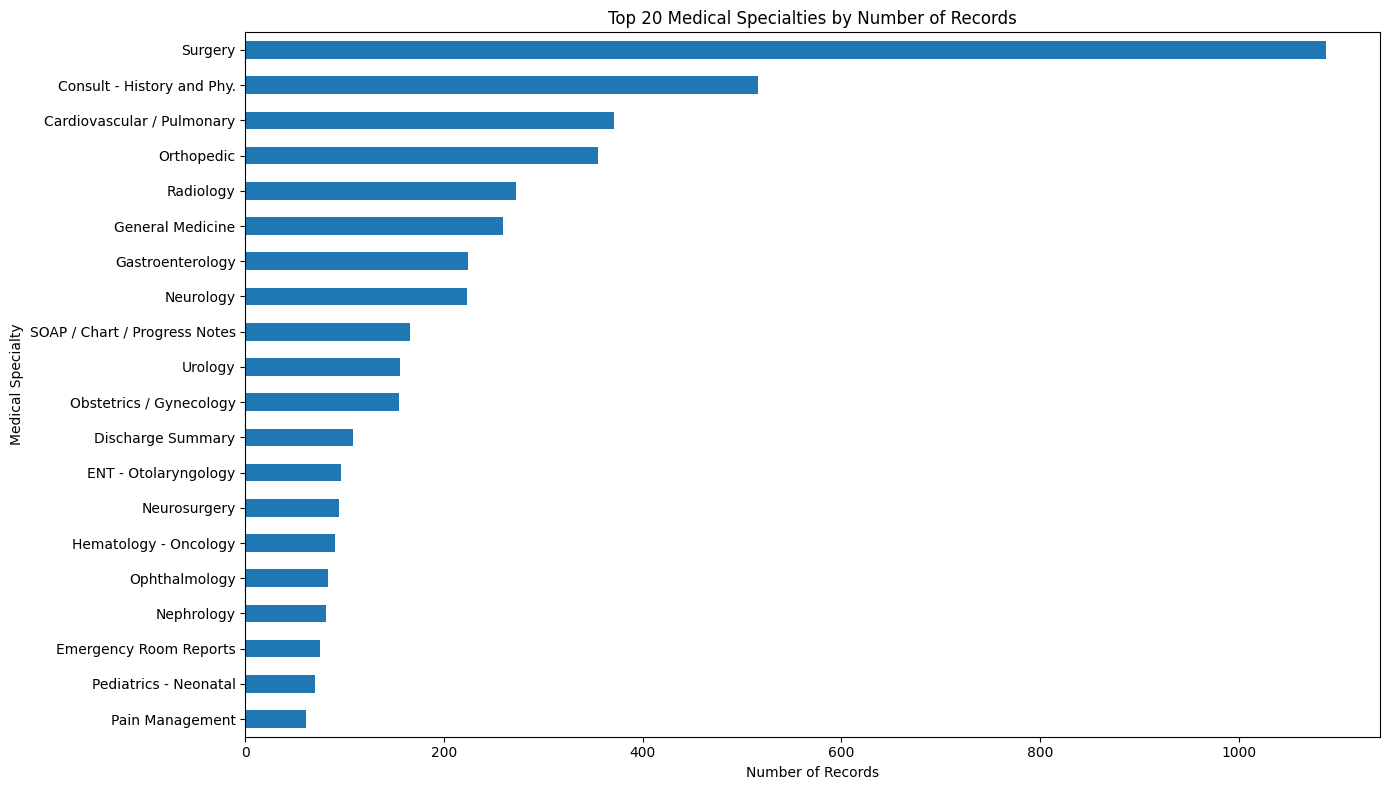

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
specialty_counts.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Medical Specialties by Number of Records")
plt.xlabel("Number of Records")
plt.ylabel("Medical Specialty")
plt.tight_layout()
plt.show()

rare_classes = specialty_counts[specialty_counts < 50]

print("Number of specialties with fewer than 50 records:", rare_classes.shape[0])
print("\nRare specialties and their counts:")
print(rare_classes)

In [11]:
rare_classes = specialty_counts[specialty_counts < 50]

print("Number of specialties with fewer than 50 records:", rare_classes.shape[0])
print("\nRare specialties and their counts:")
print(rare_classes)

Number of specialties with fewer than 50 records: 18

Rare specialties and their counts:
medical_specialty
Podiatry                      47
Dermatology                   29
Dentistry                     27
Cosmetic / Plastic Surgery    27
Letters                       23
Physical Medicine - Rehab     21
Sleep Medicine                20
Endocrinology                 19
Bariatrics                    18
IME-QME-Work Comp etc.        16
Chiropractic                  14
Diets and Nutritions          10
Rheumatology                  10
Speech - Language              9
Autopsy                        8
Lab Medicine - Pathology       8
Allergy / Immunology           7
Hospice - Palliative Care      6
Name: count, dtype: int64


## Filtering Extremely Rare Classes
In this step, we remove specialties with fewer than 50 records.

This decision is made to:
- improve class stability
- make stratified train/test splitting more reliable
- reduce noise from extremely underrepresented specialties
- create a fairer comparison across machine learning and transformer models

The removed classes will be discussed as a limitation in the final report.

In [12]:
min_samples = 50

valid_specialties = specialty_counts[specialty_counts >= min_samples].index
df_filtered = df[df["medical_specialty"].isin(valid_specialties)].copy()

print("Original dataset shape:", df.shape)
print("Filtered dataset shape:", df_filtered.shape)

print("\nNumber of specialties before filtering:", df["medical_specialty"].nunique())
print("Number of specialties after filtering:", df_filtered["medical_specialty"].nunique())

print("\nRemaining class distribution:")
print(df_filtered["medical_specialty"].value_counts())

Original dataset shape: (4966, 2)
Filtered dataset shape: (4647, 2)

Number of specialties before filtering: 40
Number of specialties after filtering: 22

Remaining class distribution:
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Psychiatry / Psychology            53

## Preparing the Final Modeling Dataset
In this step, we replace the original dataset with the filtered dataset and verify the final class distribution.

This filtered dataset will be used for:
- label encoding
- train/test splitting
- traditional machine learning models
- transformer-based models

In [13]:
df = df_filtered.copy()

print("Final modeling dataset shape:", df.shape)
print("\nFinal number of specialties:", df["medical_specialty"].nunique())

class_counts = df["medical_specialty"].value_counts()

print("\nTop 10 class counts:")
print(class_counts.head(10))

df.head()

Final modeling dataset shape: (4647, 2)

Final number of specialties: 22

Top 10 class counts:
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64


,medical_specialty,transcription
3,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...
7,Cardiovascular / Pulmonary,"2-D ECHOCARDIOGRAM,Multiple views of the heart..."
9,Cardiovascular / Pulmonary,"DESCRIPTION:,1. Normal cardiac chambers size...."
11,Cardiovascular / Pulmonary,"2-D STUDY,1. Mild aortic stenosis, widely calc..."


## Encoding the Target Labels
In this step, we convert the medical specialty names into numeric labels.

This is necessary because machine learning models work with numbers, not raw text category names.

We will also create a mapping between:
- the original specialty name
- the encoded numeric label

This mapping will help us interpret model predictions later.

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["medical_specialty"])

print("Number of encoded classes:", len(label_encoder.classes_))

label_mapping = pd.DataFrame({
    "medical_specialty": label_encoder.classes_,
    "label": range(len(label_encoder.classes_))
})

display(label_mapping.head(10))

Number of encoded classes: 22


,medical_specialty,label
0,Cardiovascular / Pulmonary,0
1,Consult - History and Phy.,1
2,Discharge Summary,2
3,ENT - Otolaryngology,3
4,Emergency Room Reports,4
5,Gastroenterology,5
6,General Medicine,6
7,Hematology - Oncology,7
8,Nephrology,8
9,Neurology,9


## Splitting the Dataset into Features and Target
In this step, we separate the input text and the target label.

- `X` will contain the transcription text
- `y` will contain the encoded specialty labels

This prepares the data for train-test splitting and model training.

In [15]:
X = df["transcription"]
y = df["label"]

print("Number of text records in X:", len(X))
print("Number of labels in y:", len(y))

print("\nSample transcription:")
print(X.iloc[0][:500])

print("\nSample encoded label:")
print(y.iloc[0])

Number of text records in X: 4647
Number of labels in y: 4647

Sample transcription:
2-D M-MODE: , ,1.  Left atrial enlargement with left atrial diameter of 4.7 cm.,2.  Normal size right and left ventricle.,3.  Normal LV systolic function with left ventricular ejection fraction of 51%.,4.  Normal LV diastolic function.,5.  No pericardial effusion.,6.  Normal morphology of aortic valve, mitral valve, tricuspid valve, and pulmonary valve.,7.  PA systolic pressure is 36 mmHg.,DOPPLER: , ,1.  Mild mitral and tricuspid regurgitation.,2.  Trace aortic and pulmonary regurgitation.

Sample encoded label:
0


## Train-Test Split
In this step, we split the dataset into training and testing sets.

We use a stratified split so that the class distribution remains similar in both sets.  
This is important for a multiclass medical classification problem with class imbalance.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

print("\nTraining class distribution (top 10):")
print(pd.Series(y_train).value_counts().head(10))

print("\nTesting class distribution (top 10):")
print(pd.Series(y_test).value_counts().head(10))

Training set size: 3717
Testing set size: 930

Training class distribution (top 10):
label
20    870
1     413
0     297
14    284
18    218
6     207
5     179
9     178
19    133
21    125
Name: count, dtype: int64

Testing class distribution (top 10):
label
20    218
1     103
0      74
14     71
18     55
6      52
5      45
9      45
19     33
21     31
Name: count, dtype: int64


## Converting Text into Numerical Features with TF-IDF
In this step, we transform the transcription text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF helps convert text into a matrix of weighted word features, where:
- common but less informative words get lower weight
- important and more distinctive words get higher weight

We will use these TF-IDF features for the traditional machine learning models:
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF training matrix shape:", X_train_tfidf.shape)
print("TF-IDF testing matrix shape:", X_test_tfidf.shape)

TF-IDF training matrix shape: (3717, 10000)
TF-IDF testing matrix shape: (930, 10000)


## Logistic Regression Model
In this step, we train the first traditional machine learning baseline: Logistic Regression.

Logistic Regression is a strong baseline for text classification because:
- it works well with TF-IDF features
- it is relatively fast to train
- it is easier to interpret than many complex models

We will train the model on the TF-IDF representation of the transcription text and then evaluate its performance on the test set.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

log_reg_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg_model.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg_model.predict(X_test_tfidf)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(
    y_test,
    y_pred_lr,
    average="macro"
)

print("Logistic Regression Results")
print("Accuracy:", round(accuracy_lr, 4))
print("Macro Precision:", round(precision_lr, 4))
print("Macro Recall:", round(recall_lr, 4))
print("Macro F1-score:", round(f1_lr, 4))

Logistic Regression Results
Accuracy: 0.3387
Macro Precision: 0.3397
Macro Recall: 0.5108
Macro F1-score: 0.3911


## Classification Report for Logistic Regression
In this step, we generate a detailed classification report for the Logistic Regression model.

This report helps us examine:
- precision for each class
- recall for each class
- F1-score for each class
- support, which is the number of true samples in each class

This is especially important for imbalanced multiclass medical data because some specialties may perform much better than others.

In [19]:
from sklearn.metrics import classification_report

class_names = label_encoder.classes_

report_lr = classification_report(
    y_test,
    y_pred_lr,
    target_names=class_names,
    digits=3
)

print(report_lr)

                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary      0.395     0.459     0.425        74
   Consult - History and Phy.      0.235     0.117     0.156       103
            Discharge Summary      0.432     0.727     0.542        22
         ENT - Otolaryngology      0.517     0.789     0.625        19
       Emergency Room Reports      0.200     0.333     0.250        15
             Gastroenterology      0.424     0.622     0.505        45
             General Medicine      0.056     0.038     0.045        52
        Hematology - Oncology      0.188     0.333     0.240        18
                   Nephrology      0.250     0.375     0.300        16
                    Neurology      0.308     0.356     0.330        45
                 Neurosurgery      0.292     0.737     0.418        19
      Obstetrics / Gynecology      0.392     0.645     0.488        31
                 Office Notes      0.250     0.700     0.368        10
     

## Confusion Matrix for Logistic Regression
In this step, we visualize the confusion matrix for the Logistic Regression model.

A confusion matrix helps us understand:
- which classes are predicted correctly
- which classes are commonly confused with other specialties
- whether the model struggles with broad categories such as Surgery or General Medicine

Because this is a multiclass problem with many specialties, the confusion matrix is especially useful for error analysis.

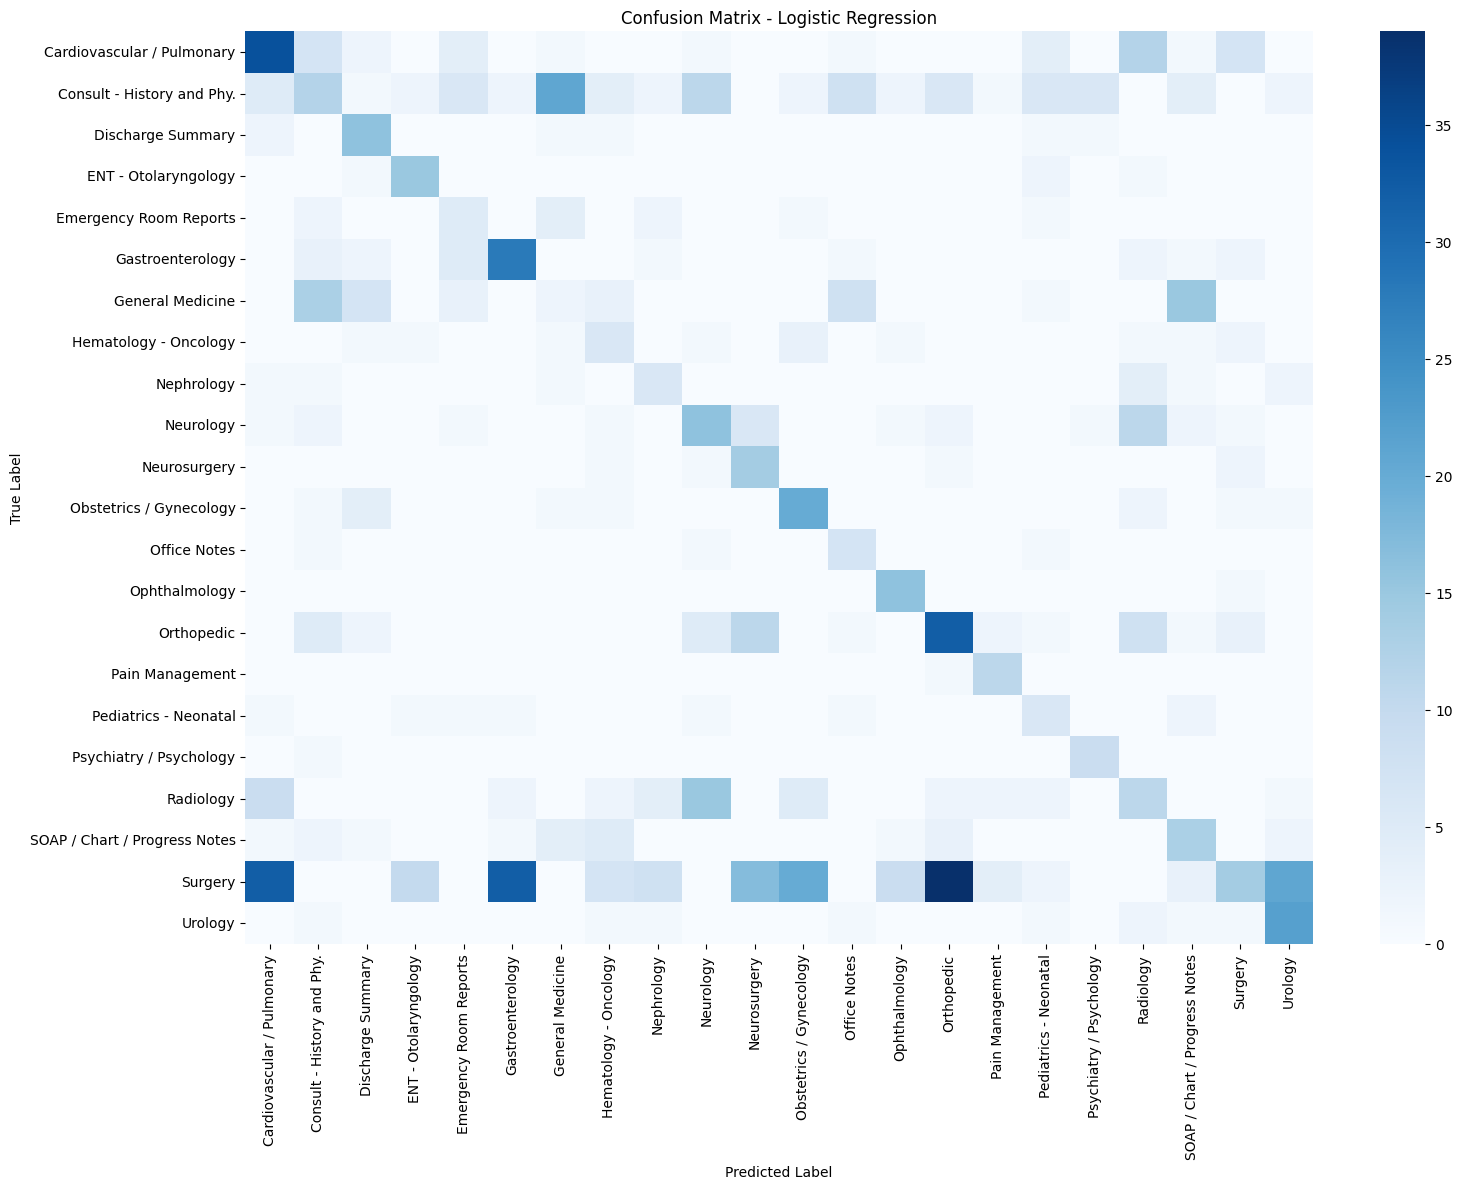

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(16, 12))
sns.heatmap(
    cm_lr,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Support Vector Machine (SVM) Model
In this step, we train the second traditional machine learning baseline: Support Vector Machine (SVM).

For text classification, a linear SVM is often a strong model because:
- it works very well with high-dimensional sparse TF-IDF features
- it often performs strongly on multiclass text problems
- it is a common benchmark for document classification tasks

We will train the model on the TF-IDF features and evaluate its performance on the test set.

In [21]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm, recall_svm, f1_svm, _ = precision_recall_fscore_support(
    y_test,
    y_pred_svm,
    average="macro"
)

print("SVM Results")
print("Accuracy:", round(accuracy_svm, 4))
print("Macro Precision:", round(precision_svm, 4))
print("Macro Recall:", round(recall_svm, 4))
print("Macro F1-score:", round(f1_svm, 4))

SVM Results
Accuracy: 0.1656
Macro Precision: 0.183
Macro Recall: 0.2338
Macro F1-score: 0.2023


## Classification Report for Support Vector Machine (SVM)
In this step, we generate a detailed classification report for the SVM model.

This report will help us understand:
- which specialties are predicted reasonably well
- which specialties are performing poorly
- whether the poor overall SVM performance is concentrated in a few classes or spread across many classes

In [22]:
report_svm = classification_report(
    y_test,
    y_pred_svm,
    target_names=label_encoder.classes_,
    digits=3
)

print(report_svm)

                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary      0.171     0.162     0.167        74
   Consult - History and Phy.      0.153     0.126     0.138       103
            Discharge Summary      0.240     0.273     0.255        22
         ENT - Otolaryngology      0.250     0.263     0.256        19
       Emergency Room Reports      0.100     0.133     0.114        15
             Gastroenterology      0.173     0.200     0.186        45
             General Medicine      0.023     0.019     0.021        52
        Hematology - Oncology      0.148     0.222     0.178        18
                   Nephrology      0.136     0.188     0.158        16
                    Neurology      0.109     0.111     0.110        45
                 Neurosurgery      0.032     0.053     0.040        19
      Obstetrics / Gynecology      0.211     0.258     0.232        31
                 Office Notes      0.130     0.300     0.182        10
     

## Random Forest Model
In this step, we train the third traditional machine learning baseline: Random Forest.

Random Forest is an ensemble learning method that combines multiple decision trees.  
It is useful because:
- it can capture non-linear patterns
- it is robust to some noise in the data
- it provides a different modeling approach compared with Logistic Regression and SVM

We will train the model using the TF-IDF features and evaluate its performance on the test set.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(
    y_test,
    y_pred_rf,
    average="macro"
)

print("Random Forest Results")
print("Accuracy:", round(accuracy_rf, 4))
print("Macro Precision:", round(precision_rf, 4))
print("Macro Recall:", round(recall_rf, 4))
print("Macro F1-score:", round(f1_rf, 4))

Random Forest Results
Accuracy: 0.1355
Macro Precision: 0.1252
Macro Recall: 0.1346
Macro F1-score: 0.1292


## Comparing the Traditional Machine Learning Baselines
In this step, we summarize the performance of the three traditional machine learning models:

- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest

This comparison helps us identify the strongest traditional baseline before moving to transformer-based models.

In [24]:
traditional_results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_svm, accuracy_rf],
    "Macro Precision": [precision_lr, precision_svm, precision_rf],
    "Macro Recall": [recall_lr, recall_svm, recall_rf],
    "Macro F1": [f1_lr, f1_svm, f1_rf]
})

traditional_results = traditional_results.round(4)
display(traditional_results.sort_values(by="Macro F1", ascending=False))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.3387,0.3397,0.5108,0.3911
1,SVM,0.1656,0.1830,0.2338,0.2023
2,Random Forest,0.1355,0.1252,0.1346,0.1292


## Visual Comparison of Traditional Model Performance
In this step, we create a bar chart to visually compare the performance of the three traditional machine learning models.

We focus on Macro F1-score because:
- this is a multiclass classification problem
- the dataset is imbalanced
- Macro F1 gives equal importance to all specialties

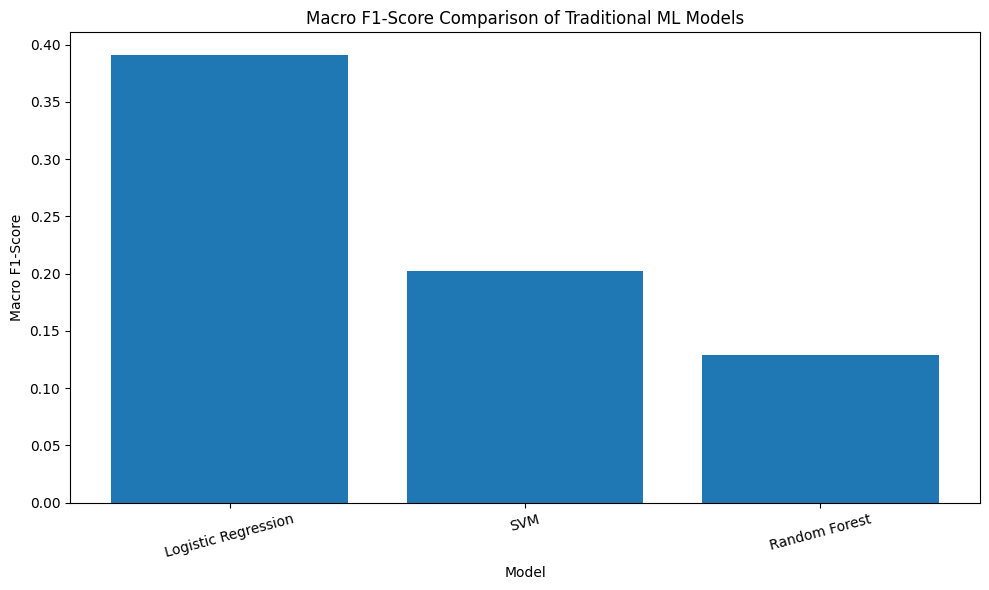

In [25]:
plt.figure(figsize=(10, 6))
plt.bar(traditional_results["Model"], traditional_results["Macro F1"])
plt.title("Macro F1-Score Comparison of Traditional ML Models")
plt.xlabel("Model")
plt.ylabel("Macro F1-Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Preparing for Transformer-Based Models
In this step, we prepare to evaluate transformer-based models for the same medical text classification task.

Unlike traditional machine learning models, transformer models do not use TF-IDF features.  
Instead, they work directly with raw text and convert it into tokenized inputs using pretrained tokenizers.

For this project, the transformer phase will later include models such as:
- RoBERTa
- Bio_ClinicalBERT
- PubMedBERT / BiomedBERT

Before training these models, we first prepare train and test data in a clean format.

In [26]:
train_df = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values
})

test_df = pd.DataFrame({
    "text": X_test.values,
    "label": y_test.values
})

print("Training dataframe shape:", train_df.shape)
print("Testing dataframe shape:", test_df.shape)

print("\nTraining dataframe preview:")
display(train_df.head())

Training dataframe shape: (3717, 2)
Testing dataframe shape: (930, 2)

Training dataframe preview:


,text,label
0,"NAME OF PROCEDURE:, Hypogastric plexus block....",15
1,"PROCEDURE:, Carpal tunnel release with transv...",20
2,"HISTORY OF PRESENT ILLNESS: , Patient is a 40-...",1
3,"PROCEDURE:, Colonoscopy.,PREOPERATIVE DIAGNOS...",20
4,"EARS, NOSE, MOUTH AND THROAT,EARS/NOSE: , The ...",3


## Installing and Importing Transformer Libraries
In this step, we prepare the environment for transformer-based modeling.

Transformer models require additional libraries for:
- pretrained tokenizers and models
- dataset handling
- training utilities
- evaluation support

We will first install the required packages in the notebook environment, and then we will verify that the imports work correctly.

In [27]:
%pip install transformers datasets accelerate evaluate sentencepiece

Note: you may need to restart the kernel to use updated packages.


## Verifying Transformer Library Imports
In this step, we verify that the required transformer libraries are installed correctly and can be imported into the notebook environment.

This confirms that the notebook is ready for transformer-based model preparation.

In [28]:
import transformers
import datasets
import evaluate
import torch

print("Transformers version:", transformers.__version__)
print("Datasets version:", datasets.__version__)
print("Evaluate version:", evaluate.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Transformers version: 5.2.0
Datasets version: 4.5.0
Evaluate version: 0.4.6
PyTorch version: 2.10.0+cpu
CUDA available: False


## Preparing Validation Data for Transformer Training
In this step, we create a validation split from the training data.

Transformer models usually need:
- a training set
- a validation set
- a test set

The validation set helps us monitor model performance during training and reduce overfitting.

In [29]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"],
    train_df["label"],
    test_size=0.10,
    random_state=42,
    stratify=train_df["label"]
)

print("Transformer training set size:", len(train_texts))
print("Transformer validation set size:", len(val_texts))
print("Transformer test set size:", len(test_df))

print("\nSample training text:")
print(train_texts.iloc[0][:400])

print("\nSample training label:")
print(train_labels.iloc[0])

Transformer training set size: 3345
Transformer validation set size: 372
Transformer test set size: 930

Sample training text:
PREOPERATIVE DIAGNOSIS: , Right hip osteoarthritis.,POSTOPERATIVE DIAGNOSIS: , Right hip osteoarthritis.,PROCEDURES PERFORMED: , Total hip replacement on the right side using the following components:,1.  Zimmer trilogy acetabular system 10-degree elevated rim located at the 12 o'clock position.,2.  Trabecular metal modular acetabular system 48 mm in diameter.,3.  Femoral head 32 mm diameter +0 mm

Sample training label:
20


## Loading the RoBERTa Tokenizer
In this step, we load the tokenizer for the RoBERTa model.

A tokenizer converts raw text into token IDs that the transformer model can understand.  
It also handles:
- truncation of long text
- padding
- attention masks

We will use the tokenizer first before creating the transformer datasets.

In [30]:
from transformers import AutoTokenizer

roberta_model_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_model_name)

print("Tokenizer loaded successfully for:", roberta_model_name)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully for: roberta-base


## Creating and Tokenizing the RoBERTa Datasets
In this step, we convert the training, validation, and test data into Hugging Face datasets and tokenize the text using the RoBERTa tokenizer.

This prepares the data in the format required for transformer model training and evaluation.

In [31]:
from datasets import Dataset

# Create Hugging Face datasets
train_dataset = Dataset.from_dict({
    "text": train_texts.tolist(),
    "label": train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    "text": val_texts.tolist(),
    "label": val_labels.tolist()
})

test_dataset = Dataset.from_dict({
    "text": test_df["text"].tolist(),
    "label": test_df["label"].tolist()
})

# Tokenization function
def tokenize_function(examples):
    return roberta_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

# Apply tokenization
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

print("Tokenization completed.")
print("Training dataset size:", len(tokenized_train))
print("Validation dataset size:", len(tokenized_val))
print("Test dataset size:", len(tokenized_test))

Map:   0%|          | 0/3345 [00:00<?, ? examples/s]

Map:   0%|          | 0/372 [00:00<?, ? examples/s]

Map:   0%|          | 0/930 [00:00<?, ? examples/s]

Tokenization completed.
Training dataset size: 3345
Validation dataset size: 372
Test dataset size: 930


## Loading the RoBERTa Classification Model
In this step, we load the pretrained RoBERTa model for sequence classification.

This model has already learned general language patterns from large text corpora.  
We now adapt it to our medical text classification problem by setting the number of output labels equal to the number of medical specialties in our dataset.

In [32]:
from transformers import AutoModelForSequenceClassification

num_labels = len(label_encoder.classes_)

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=num_labels
)

print("RoBERTa model loaded successfully.")
print("Number of output labels:", roberta_model.config.num_labels)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa model loaded successfully.
Number of output labels: 22


## Formatting the Tokenized Datasets for PyTorch
In this step, we prepare the tokenized datasets for transformer training.

The Hugging Face Trainer expects:
- tokenized input fields such as `input_ids` and `attention_mask`
- the target label
- PyTorch tensor format

So we remove the raw text column and set the dataset format for PyTorch.

In [33]:
columns_to_keep = ["input_ids", "attention_mask", "label"]

tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format(type="torch", columns=columns_to_keep)
tokenized_val.set_format(type="torch", columns=columns_to_keep)
tokenized_test.set_format(type="torch", columns=columns_to_keep)

print("Tokenized datasets formatted for PyTorch.")
print("Training sample keys:", tokenized_train[0].keys())
print("Input ID tensor shape for one sample:", tokenized_train[0]["input_ids"].shape)

Tokenized datasets formatted for PyTorch.
Training sample keys: dict_keys(['label', 'input_ids', 'attention_mask'])
Input ID tensor shape for one sample: torch.Size([256])


## Defining the Evaluation Metrics for RoBERTa
In this step, we define a function to evaluate the RoBERTa model during training and validation.

We will use:
- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score

Macro F1 is especially important for this project because the dataset is imbalanced and we want to give equal importance to all medical specialties.

In [34]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )
    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

print("Metric function defined successfully.")

Metric function defined successfully.


## Defining the Training Configuration for RoBERTa
In this step, we define the training arguments for the RoBERTa model.

These settings control:
- how many training epochs to run
- batch size
- evaluation frequency
- model checkpoint saving
- loading the best model at the end

Because this system is running on CPU only, we use a lightweight configuration to keep training manageable.

In [35]:
from transformers import TrainingArguments

roberta_training_args = TrainingArguments(
    output_dir="./roberta_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none"
)

print("RoBERTa training arguments created successfully.")

RoBERTa training arguments created successfully.


## Creating the Hugging Face Trainer for RoBERTa
In this step, we create the Hugging Face `Trainer` object.

The Trainer brings together:
- the pretrained RoBERTa model
- the training arguments
- the tokenized training and validation datasets
- the tokenizer
- the evaluation metrics function

This object will manage the training and validation process for the transformer model.

In [36]:
from transformers import Trainer

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=roberta_tokenizer,
    compute_metrics=compute_metrics
)

print("RoBERTa Trainer created successfully.")

RoBERTa Trainer created successfully.


## Training the RoBERTa Model
In this step, we start training the RoBERTa model on the tokenized medical transcription data.

During training:
- the model learns patterns from the training set
- validation performance is checked after each epoch
- the best model is retained based on Macro F1-score

Because the environment is CPU-only, this step may take some time.

In [37]:
roberta_train_result = roberta_trainer.train()
print("RoBERTa training completed.")

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,2.333627,2.150300,0.354839,0.103922,0.122301,0.087898
2,1.832041,1.789690,0.368280,0.214689,0.169819,0.162883


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

RoBERTa training completed.


## Recording RoBERTa Validation Results
In this step, we store the RoBERTa validation metrics so they can be compared later with:
- traditional machine learning models
- Bio_ClinicalBERT

In [38]:
roberta_results = {
    "Model": "RoBERTa",
    "Accuracy": 0.3683,
    "Macro Precision": 0.2147,
    "Macro Recall": 0.1698,
    "Macro F1": 0.1629
}

roberta_results_df = pd.DataFrame([roberta_results])
display(roberta_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,RoBERTa,0.3683,0.2147,0.1698,0.1629


## Loading the Bio_ClinicalBERT Tokenizer
In this step, we load the tokenizer for Bio_ClinicalBERT.

Bio_ClinicalBERT is a domain-specific transformer model trained on clinical text, so it is expected to understand medical language better than a general-purpose model such as RoBERTa.

For this comparison, we use a lighter configuration to keep training practical on a CPU-only system.

In [39]:
from transformers import AutoTokenizer

clinicalbert_model_name = "emilyalsentzer/Bio_ClinicalBERT"
clinicalbert_tokenizer = AutoTokenizer.from_pretrained(clinicalbert_model_name)

print("Tokenizer loaded successfully for:", clinicalbert_model_name)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully for: emilyalsentzer/Bio_ClinicalBERT


## Tokenizing the Data for Bio_ClinicalBERT
In this step, we tokenize the training, validation, and test data using the Bio_ClinicalBERT tokenizer.

To reduce training time on CPU, we use a shorter maximum sequence length of 128 tokens for this model.

In [40]:
from datasets import Dataset

# Recreate Hugging Face datasets from the same text splits
clinical_train_dataset = Dataset.from_dict({
    "text": train_texts.tolist(),
    "label": train_labels.tolist()
})

clinical_val_dataset = Dataset.from_dict({
    "text": val_texts.tolist(),
    "label": val_labels.tolist()
})

clinical_test_dataset = Dataset.from_dict({
    "text": test_df["text"].tolist(),
    "label": test_df["label"].tolist()
})

def clinicalbert_tokenize_function(examples):
    return clinicalbert_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

clinical_tokenized_train = clinical_train_dataset.map(clinicalbert_tokenize_function, batched=True)
clinical_tokenized_val = clinical_val_dataset.map(clinicalbert_tokenize_function, batched=True)
clinical_tokenized_test = clinical_test_dataset.map(clinicalbert_tokenize_function, batched=True)

print("Bio_ClinicalBERT tokenization completed.")
print("Training dataset size:", len(clinical_tokenized_train))
print("Validation dataset size:", len(clinical_tokenized_val))
print("Test dataset size:", len(clinical_tokenized_test))

Map:   0%|          | 0/3345 [00:00<?, ? examples/s]

Map:   0%|          | 0/372 [00:00<?, ? examples/s]

Map:   0%|          | 0/930 [00:00<?, ? examples/s]

Bio_ClinicalBERT tokenization completed.
Training dataset size: 3345
Validation dataset size: 372
Test dataset size: 930


## Formatting the Bio_ClinicalBERT Datasets for PyTorch
In this step, we remove the raw text column and convert the tokenized datasets into PyTorch format.

This prepares the Bio_ClinicalBERT inputs for training with the Hugging Face Trainer.

In [41]:
clinical_columns_to_keep = ["input_ids", "attention_mask", "label"]

clinical_tokenized_train = clinical_tokenized_train.remove_columns(["text"])
clinical_tokenized_val = clinical_tokenized_val.remove_columns(["text"])
clinical_tokenized_test = clinical_tokenized_test.remove_columns(["text"])

clinical_tokenized_train.set_format(type="torch", columns=clinical_columns_to_keep)
clinical_tokenized_val.set_format(type="torch", columns=clinical_columns_to_keep)
clinical_tokenized_test.set_format(type="torch", columns=clinical_columns_to_keep)

print("Bio_ClinicalBERT datasets formatted for PyTorch.")
print("Training sample keys:", clinical_tokenized_train[0].keys())
print("Input ID tensor shape for one sample:", clinical_tokenized_train[0]["input_ids"].shape)

Bio_ClinicalBERT datasets formatted for PyTorch.
Training sample keys: dict_keys(['label', 'input_ids', 'attention_mask'])
Input ID tensor shape for one sample: torch.Size([128])


## Loading the Bio_ClinicalBERT Classification Model
In this step, we load the pretrained Bio_ClinicalBERT model for sequence classification.

The model is adapted to our task by setting the number of output labels equal to the number of medical specialties in the dataset.

In [42]:
from transformers import AutoModelForSequenceClassification

clinicalbert_model = AutoModelForSequenceClassification.from_pretrained(
    clinicalbert_model_name,
    num_labels=num_labels
)

print("Bio_ClinicalBERT model loaded successfully.")
print("Number of output labels:", clinicalbert_model.config.num_labels)

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Bio_ClinicalBERT model loaded successfully.
Number of output labels: 22


## Defining the Training Configuration for Bio_ClinicalBERT
In this step, we define a lighter training configuration for Bio_ClinicalBERT.

To keep the run practical on a CPU-only system, we use:
- 1 training epoch
- shorter input length already set to 128
- batch size 8
- validation at the end of the epoch

In [43]:
from transformers import TrainingArguments

clinicalbert_training_args = TrainingArguments(
    output_dir="./clinicalbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none"
)

print("Bio_ClinicalBERT training arguments created successfully.")

Bio_ClinicalBERT training arguments created successfully.


## Creating the Hugging Face Trainer for Bio_ClinicalBERT
In this step, we create the Hugging Face `Trainer` object for Bio_ClinicalBERT.

The Trainer combines:
- the Bio_ClinicalBERT model
- the training configuration
- the tokenized training and validation datasets
- the tokenizer
- the evaluation metrics function

This object will manage model training and validation.

In [44]:
from transformers import Trainer

clinicalbert_trainer = Trainer(
    model=clinicalbert_model,
    args=clinicalbert_training_args,
    train_dataset=clinical_tokenized_train,
    eval_dataset=clinical_tokenized_val,
    processing_class=clinicalbert_tokenizer,
    compute_metrics=compute_metrics
)

print("Bio_ClinicalBERT Trainer created successfully.")

Bio_ClinicalBERT Trainer created successfully.


## Training the Bio_ClinicalBERT Model
In this step, we start training the Bio_ClinicalBERT model on the tokenized medical transcription data.

During training:
- the model learns from the training set
- validation is performed at the end of the epoch
- the best checkpoint is retained based on Macro F1-score

This run is lighter than RoBERTa because it uses:
- 1 epoch
- sequence length of 128

In [45]:
clinicalbert_train_result = clinicalbert_trainer.train()
print("Bio_ClinicalBERT training completed.")

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,2.150008,1.909281,0.327957,0.113872,0.124681,0.106757


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Bio_ClinicalBERT training completed.


## Recording Bio_ClinicalBERT Results and Creating the Final Comparison Table
In this step, we record the Bio_ClinicalBERT validation metrics and combine them with the traditional machine learning and RoBERTa results.

This creates a single summary table for the final project analysis.

In [46]:
bio_clinicalbert_results = {
    "Model": "Bio_ClinicalBERT",
    "Accuracy": 0.3280,
    "Macro Precision": 0.1139,
    "Macro Recall": 0.1247,
    "Macro F1": 0.1068
}

roberta_results = {
    "Model": "RoBERTa",
    "Accuracy": 0.3683,
    "Macro Precision": 0.2147,
    "Macro Recall": 0.1698,
    "Macro F1": 0.1629
}

traditional_results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_svm, accuracy_rf],
    "Macro Precision": [precision_lr, precision_svm, precision_rf],
    "Macro Recall": [recall_lr, recall_svm, recall_rf],
    "Macro F1": [f1_lr, f1_svm, f1_rf]
})

transformer_results = pd.DataFrame([roberta_results, bio_clinicalbert_results])

final_results = pd.concat([traditional_results, transformer_results], ignore_index=True)
final_results = final_results.round(4)

display(final_results.sort_values(by="Macro F1", ascending=False).reset_index(drop=True))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.3387,0.3397,0.5108,0.3911
1,SVM,0.1656,0.1830,0.2338,0.2023
2,RoBERTa,0.3683,0.2147,0.1698,0.1629
3,Random Forest,0.1355,0.1252,0.1346,0.1292
4,Bio_ClinicalBERT,0.3280,0.1139,0.1247,0.1068


## Final Interpretation of Model Comparison Results
In this step, we summarize and interpret the overall results across all evaluated models.

This comparison helps identify:
- which model performed best overall
- how traditional machine learning compared with transformer models
- what trade-offs emerged between simplicity, domain specificity, and performance

Because this is an imbalanced multiclass medical text classification task, Macro F1-score is used as the most important comparison metric.

In [47]:
best_model_row = final_results.sort_values(by="Macro F1", ascending=False).iloc[0]

print("Final Model Ranking by Macro F1:\n")
display(final_results.sort_values(by="Macro F1", ascending=False).reset_index(drop=True))

print(f"\nBest overall model: {best_model_row['Model']}")
print(f"Best Macro F1-score: {best_model_row['Macro F1']:.4f}")
print(f"Best Accuracy: {best_model_row['Accuracy']:.4f}")

print("\nKey Interpretation:")
print("- Logistic Regression achieved the best overall Macro F1-score, making it the strongest model for balanced multiclass performance.")
print("- RoBERTa outperformed Bio_ClinicalBERT, but both transformer models underperformed compared with Logistic Regression in this project setup.")
print("- SVM and Random Forest performed worse than Logistic Regression, with Random Forest showing the weakest traditional baseline performance.")
print("- The transformer models were likely limited by CPU-only training, short training schedules, and class imbalance in the dataset.")

Final Model Ranking by Macro F1:



,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.3387,0.3397,0.5108,0.3911
1,SVM,0.1656,0.1830,0.2338,0.2023
2,RoBERTa,0.3683,0.2147,0.1698,0.1629
3,Random Forest,0.1355,0.1252,0.1346,0.1292
4,Bio_ClinicalBERT,0.3280,0.1139,0.1247,0.1068



Best overall model: Logistic Regression
Best Macro F1-score: 0.3911
Best Accuracy: 0.3387

Key Interpretation:
- Logistic Regression achieved the best overall Macro F1-score, making it the strongest model for balanced multiclass performance.
- RoBERTa outperformed Bio_ClinicalBERT, but both transformer models underperformed compared with Logistic Regression in this project setup.
- SVM and Random Forest performed worse than Logistic Regression, with Random Forest showing the weakest traditional baseline performance.
- The transformer models were likely limited by CPU-only training, short training schedules, and class imbalance in the dataset.


## Visual Comparison of All Evaluated Models
In this step, we create a bar chart to compare the Macro F1-scores of all evaluated models.

This visualization helps us clearly see:
- which model performed best
- how the traditional machine learning baselines compare with the transformer models
- the performance gap between simpler and more complex approaches

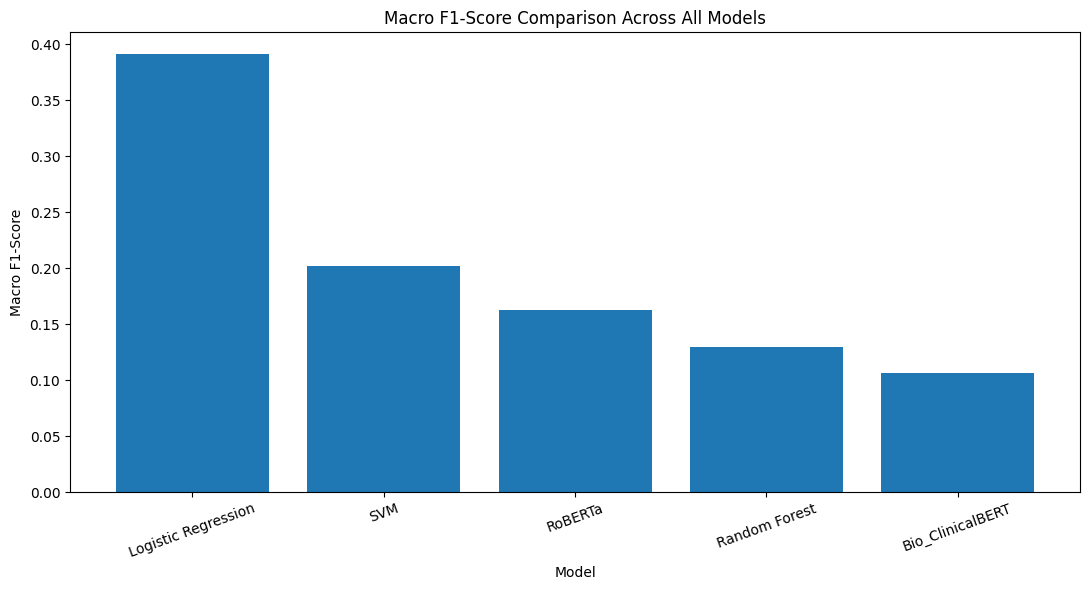

In [48]:
results_sorted = final_results.sort_values(by="Macro F1", ascending=False)

plt.figure(figsize=(11, 6))
plt.bar(results_sorted["Model"], results_sorted["Macro F1"])
plt.title("Macro F1-Score Comparison Across All Models")
plt.xlabel("Model")
plt.ylabel("Macro F1-Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Conclusion and Key Findings

This project evaluated multiple models for medical text classification using the Medical Transcriptions dataset. The comparison included three traditional machine learning models and two transformer-based models.

### Summary of Findings
- **Logistic Regression** achieved the best overall performance based on Macro F1-score, making it the strongest model for this imbalanced multiclass classification task.
- **SVM** performed worse than Logistic Regression but still outperformed the transformer models in this specific setup.
- **Random Forest** showed the weakest performance among the traditional machine learning baselines, likely because sparse TF-IDF text features are not ideal for tree-based ensemble methods.
- **RoBERTa** performed better than **Bio_ClinicalBERT**, but both transformer models underperformed compared with Logistic Regression in the current experimental setting.
- The transformer models were likely limited by practical constraints such as:
  - CPU-only training
  - short training schedules
  - reduced sequence lengths
  - class imbalance in the dataset

### Overall Conclusion
For this project, **Logistic Regression with TF-IDF features was the most effective model** when considering balanced multiclass performance. Although transformer models are more advanced and context-aware, they did not outperform the simpler baseline under the available training conditions.

### Practical Recommendation
Based on these results, Logistic Regression would be the preferred model for this dataset in a resource-constrained environment. Transformer-based approaches remain promising, but they would likely require:
- GPU-based training
- more epochs
- better hyperparameter tuning
- class imbalance handling
- deeper domain adaptation

### Future Improvements
Future work could include:
- testing additional domain-specific transformer models
- using class-weighted loss functions for transformers
- applying longer training schedules
- performing hyperparameter tuning
- evaluating explainability methods such as SHAP or attention visualization
- testing robustness more extensively on noisy or truncated clinical text